In [1]:
import numpy as np
import pandas as pd
import pydicom
import os
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold

In [2]:
import tensorflow as tf
import tensorflow.keras.backend as K
import tensorflow.keras.layers as L
import tensorflow.keras.models as M

2026-04-28 02:48:07.961994: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 02:48:07.973912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777344487.985577      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777344487.989024      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-28 02:48:08.002823: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
def seed_everything(seed=2020):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    return seed

In [4]:
ROOT = "../input/osic-pulmonary-fibrosis-progression"

tr = pd.read_csv(f"{ROOT}/train.csv")
tr.drop_duplicates(keep=False, inplace=True, subset=['Patient','Weeks'])
chunk = pd.read_csv(f"{ROOT}/test.csv")

print("add infos")
sub = pd.read_csv(f"{ROOT}/sample_submission.csv")
sub['Patient'] = sub['Patient_Week'].apply(lambda x:x.split('_')[0])
sub['Weeks'] = sub['Patient_Week'].apply(lambda x: int(x.split('_')[-1]))
sub =  sub[['Patient','Weeks','Confidence','Patient_Week']]
sub = sub.merge(chunk.drop('Weeks', axis=1), on="Patient")

add infos


In [5]:
tr['WHERE'] = 'train'
chunk['WHERE'] = 'val'
sub['WHERE'] = 'test'
data = tr.append([chunk, sub])

AttributeError: 'DataFrame' object has no attribute 'append'

In [6]:
print(tr.shape, chunk.shape, sub.shape, data.shape)
print(tr.Patient.nunique(), chunk.Patient.nunique(), sub.Patient.nunique(), 
      data.Patient.nunique())
#

NameError: name 'data' is not defined

In [7]:
data['min_week'] = data['Weeks']
data.loc[data.WHERE=='test','min_week'] = np.nan
data['min_week'] = data.groupby('Patient')['min_week'].transform('min')

NameError: name 'data' is not defined

In [8]:
base = data.loc[data.Weeks == data.min_week]
base = base[['Patient','FVC']].copy()
base.columns = ['Patient','min_FVC']
base['nb'] = 1
base['nb'] = base.groupby('Patient')['nb'].transform('cumsum')
base = base[base.nb==1]
base.drop('nb', axis=1, inplace=True)

NameError: name 'data' is not defined

In [9]:
data = data.merge(base, on='Patient', how='left')
data['base_week'] = data['Weeks'] - data['min_week']
del base

NameError: name 'data' is not defined

In [10]:
COLS = ['Sex','SmokingStatus']
FE = []
for col in COLS:
    for mod in data[col].unique():
        FE.append(mod)
        data[mod] = (data[col] == mod).astype(int)
#=================

NameError: name 'data' is not defined

In [11]:

data['age'] = (data['Age'] - data['Age'].min() ) / ( data['Age'].max() - data['Age'].min() )
data['BASE'] = (data['min_FVC'] - data['min_FVC'].min() ) / ( data['min_FVC'].max() - data['min_FVC'].min() )
data['week'] = (data['base_week'] - data['base_week'].min() ) / ( data['base_week'].max() - data['base_week'].min() )
data['percent'] = (data['Percent'] - data['Percent'].min() ) / ( data['Percent'].max() - data['Percent'].min() )
FE += ['age','percent','week','BASE']
#FE += ['age','percent','BASE']

NameError: name 'data' is not defined

In [12]:
tr = data.loc[data.WHERE=='train']
chunk = data.loc[data.WHERE=='val']
sub = data.loc[data.WHERE=='test']
del data

NameError: name 'data' is not defined

In [13]:
tr.to_csv('tr.csv', index = False)
chunk.to_csv('chunk.csv', index = False)
sub.to_csv('sub.csv', index = False)

In [14]:
# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 8))

# ax1.set_title('Before Scaling')
# sns.kdeplot(df_before_scale['Weeks'], ax=ax1)
# sns.kdeplot(df_before_scale['FVC'], ax=ax1)
# sns.kdeplot(df_before_scale['Percent'], ax=ax1)
# sns.kdeplot(df_before_scale['Age'], ax=ax1)
# sns.kdeplot(df_before_scale['visit'], ax=ax1)
# sns.kdeplot(df_before_scale['base_week'], ax=ax1)
# sns.kdeplot(df_before_scale['base_FVC'], ax=ax1)
# sns.kdeplot(df_before_scale['base_percent'],  ax=ax1)
# sns.kdeplot(df_before_scale['base_age'],  ax=ax1)
# sns.kdeplot(df_before_scale['weeks_passed'],  ax=ax1)


In [15]:
#tr.shape, chunk.shape, sub.shape

In [16]:
SEED = seed_everything(42)
NFOLD        = 5
EPOCHS       = 800
BATCH_SIZE   = 128

M_LOSS       = 0.775
LR           = 0.1
DECAY        = 0.01     #0099999

kf = KFold(n_splits=NFOLD)

### BASELINE NN 

In [17]:
C1, C2 = tf.constant(70, dtype='float32'), tf.constant(1000, dtype="float32")
#=============================#
def score(y_true, y_pred):
    tf.dtypes.cast(y_true, tf.float32)
    tf.dtypes.cast(y_pred, tf.float32)
    sigma = y_pred[:, 2] - y_pred[:, 0]
    fvc_pred = y_pred[:, 1]
    
    #sigma_clip = sigma + C1
    sigma_clip = tf.maximum(sigma, C1)
    delta = tf.abs(y_true[:, 0] - fvc_pred)
    delta = tf.minimum(delta, C2)
    sq2 = tf.sqrt( tf.dtypes.cast(2, dtype=tf.float32) )
    metric = (delta / sigma_clip)*sq2 + tf.math.log(sigma_clip* sq2)
    return K.mean(metric)
#============================#
def qloss(y_true, y_pred):
    # Pinball loss for multiple quantiles
    qs = [0.2, 0.5, 0.8]
    q = tf.constant(np.array([qs]), dtype=tf.float32)
    e = y_true - y_pred
    v = tf.maximum(q*e, (q-1)*e)
    return K.mean(v)
#=============================#
def mloss(_lambda):
    def loss(y_true, y_pred):
        return _lambda * qloss(y_true, y_pred) + (1 - _lambda)*score(y_true, y_pred)
    return loss
#=================
def make_model():
    z = L.Input((9,), name="Patient")
    x = L.Dense(120, activation="relu", name="d1")(z)
    #x = L.Dropout(0.05)(x)
    x = L.Dense(120, activation="relu", name="d2")(x)
    #x = L.Dense(100, activation="relu", name="d3")(x)
    p1 = L.Dense(3, activation="linear", name="p1")(x)  # sigmoid
    p2 = L.Dense(3, activation="relu", name="p2")(x)
    preds = L.Lambda(lambda x: x[0] + tf.cumsum(x[1], axis=1), 
                     name="preds")([p1, p2])
    
    
    model = M.Model(z, preds, name="ANN") #LR BETA_1 BETA_2 DECAY
    #model.compile(loss=qloss, optimizer="adam", metrics=[score])
    model.compile(loss=mloss(M_LOSS), optimizer=tf.keras.optimizers.Adagrad(lr= LR , 
              ), metrics=[score])# epsilon=None,
    return model
#loss=mloss(0.775) 

2026-04-28 02:48:13.858788: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [18]:
net = make_model()
print(net.summary())
print(net.count_params())

ValueError: Argument(s) not recognized: {'lr': 0.1}

In [19]:
tr[FE].columns

Index([], dtype='object')

In [20]:
y = tr['FVC'].values
z = tr[FE].values
ze = sub[FE].values
pe = np.zeros((ze.shape[0], 3))
pred = np.zeros((z.shape[0], 3))
delta = np.zeros((z.shape[0], 3))

In [21]:
%%time
cnt = 0
train = []
val   = []


for tr_idx, val_idx in kf.split(z):
    cnt += 1
    print(f"FOLD {cnt}")
    
    
    net = make_model()
    
    
    net.fit(z[tr_idx], y[tr_idx], batch_size=BATCH_SIZE, epochs= EPOCHS, 
            validation_data=(z[val_idx], y[val_idx]), verbose=0) #
    
#     train.append(net.evaluate(z[tr_idx], y[tr_idx], batch_size=BATCH_SIZE))
#     val.append(net.evaluate(z[val_idx], y[val_idx], batch_size=BATCH_SIZE)
    print("train", net.evaluate(z[tr_idx], y[tr_idx], verbose=0, batch_size=BATCH_SIZE))
    print("val", net.evaluate(z[val_idx], y[val_idx], verbose=0, batch_size=BATCH_SIZE))
    #print("predict val...")
    pred[val_idx] = net.predict(z[val_idx], batch_size=BATCH_SIZE, verbose=0)
    #print("predict test...")
    print()
    pe += net.predict(ze, batch_size=BATCH_SIZE, verbose=0) / NFOLD
    
    delta += net.predict(z) / NFOLD
    
    
#==============



FOLD 1


ValueError: Argument(s) not recognized: {'lr': 0.1}

In [22]:
sigma_opt = mean_absolute_error(y, pred[:, 1])
unc = pred[:,2] - pred[:, 0]
sigma_mean = np.mean(unc)
print(sigma_opt, sigma_mean)
#142.3356196400397 234.99396579009314

2668.453623188406 0.0


In [23]:
# Scoring

o_clipped = np.maximum(delta[:,2] - delta[:,0], 70)
delta = np.minimum(np.abs(delta[:, 1] - y), 1000)
sqrt = (np.sqrt((2)))
score = (-(sqrt * (delta))/(o_clipped)) - tf.math.log(sqrt * o_clipped)

logL_Score = np.mean(score)

In [24]:
print('we are using fix seed value always to avoid RANDOMIZATION (NEED TO GET SAME RESULT)')
print('Seed value          =',SEED)
print('Number of folds     =',BATCH_SIZE)
print('Number of epochs    =',EPOCHS)

print('\nmean_absolute_error =',sigma_opt)
#print('unc_mean            =',unc_mean)

print('unc_mean            =',unc.mean())
print()
print('Log_laplace_Scores  =',logL_Score )
print()
print('unc_min             =',unc.min())
print('unc_max             =',unc.max())
print('unc_mean            =',(unc>=0).mean())

we are using fix seed value always to avoid RANDOMIZATION (NEED TO GET SAME RESULT)
Seed value          = 42
Number of folds     = 128
Number of epochs    = 800

mean_absolute_error = 2668.453623188406
unc_mean            = 0.0

Log_laplace_Scores  = -24.790711938046837

unc_min             = 0.0
unc_max             = 0.0
unc_mean            = 1.0


In [25]:
# # # # ########### RUN FIRST TIME ONLY ################
stats = pd.DataFrame()
index = 0

In [26]:
data = [[index, logL_Score, sigma_opt, unc.mean(), unc.min(),  unc.max(), (unc>=0).mean(),
         BATCH_SIZE, EPOCHS,  NFOLD, M_LOSS, LR, DECAY ,SEED]]
columns = ['S.No','Score', 'meanAbseErr', 'unc.mean', 'unc.min', 'unc.max',  '(unc>=0)',
           'Bsize', 'epoch', 'NFOLD', 'M_LOSS', 'LR', 'DECAY', 'seed']
kernal_stats = pd.DataFrame(data, columns=columns)
# print("current kernal state")
kernal_stats

,S.No,Score,meanAbseErr,unc.mean,unc.min,unc.max,(unc>=0),Bsize,epoch,NFOLD,M_LOSS,LR,DECAY,seed
0,0,-24.790712,2668.453623,0.0,0.0,0.0,1.0,128,800,5,0.775,0.1,0.01,42


In [27]:
stats = pd.concat([stats, kernal_stats])
stats.to_csv('kernal.csv', index = False)
index+=1
# 154.68119019747556 213.12221373517662 0.0 213.12221373517662 384.3486328125 1.0
# print('kernal stats of every version')
stats

#0 -6.490188 142.335620 234.993966 25.237061 485.192871 1.0 128 800 5 0.775 0.100 0.010 42
#3 -6.488414	141.404185	234.008693	20.999268	495.660645	1.0	128	850	5	0.775	0.1	0.01	42

,S.No,Score,meanAbseErr,unc.mean,unc.min,unc.max,(unc>=0),Bsize,epoch,NFOLD,M_LOSS,LR,DECAY,seed
0,0,-24.790712,2668.453623,0.0,0.0,0.0,1.0,128,800,5,0.775,0.1,0.01,42


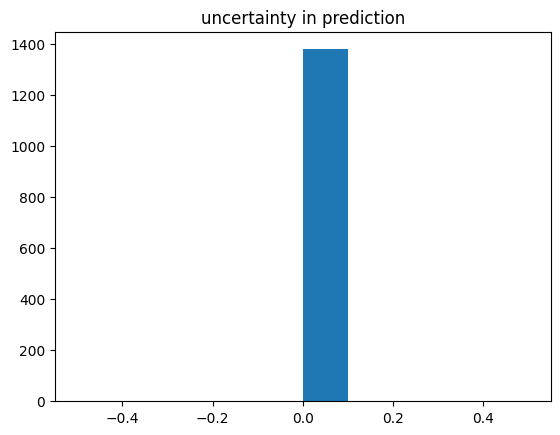

In [28]:
plt.hist(unc)
plt.title("uncertainty in prediction")
#plt.savefig('plt_unc_pred{}.png'.format(index))
plt.show()

In [29]:
# plt.plot(arr)
# plt.xlabel('epoch')
# plt.ylabel('accuracy')
# plt.title('Accuracy vs. No. of epochs');

In [30]:
# idxs = np.random.randint(0, y.shape[0], 100)
# plt.plot(y[idxs], label="ground truth")
# plt.plot(pred[idxs, 0], label="q25")
# plt.plot(pred[idxs, 1], label="q50")
# plt.plot(pred[idxs, 2], label="q75")
# plt.legend(loc="best")
# plt.show()

/tmp/ipykernel_11/1092048599.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(unc)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/distributions.py:2511: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


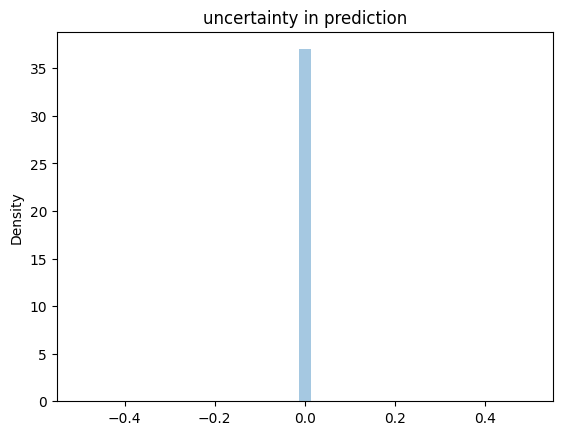

In [31]:
import seaborn as sns
sns.distplot(unc)
#plt.(unc)
plt.title("uncertainty in prediction")
# plt.savefig('sns_unc_pred{}.png'.format(index))
plt.show()

### PREDICTION

In [32]:
#sub.head()

In [33]:
sub['FVC1'] = pe[:, 1]
sub['Confidence1'] = pe[:, 2] - pe[:, 0]

In [34]:
subm = sub[['Patient_Week','FVC','Confidence','FVC1','Confidence1']].copy()

In [35]:
subm.loc[~subm.FVC1.isnull()].head(1)

,Patient_Week,FVC,Confidence,FVC1,Confidence1
0,ID00126637202218610655908_-3,2375,100,0.0,0.0


In [36]:
subm.loc[~subm.FVC1.isnull(),'FVC'] = subm.loc[~subm.FVC1.isnull(),'FVC1']
if sigma_mean<70:
    subm['Confidence'] = sigma_opt
else:
    subm.loc[~subm.FVC1.isnull(),'Confidence'] = subm.loc[~subm.FVC1.isnull(),'Confidence1']

In [37]:
subm.head(1)

,Patient_Week,FVC,Confidence,FVC1,Confidence1
0,ID00126637202218610655908_-3,0,2668.453623,0.0,0.0


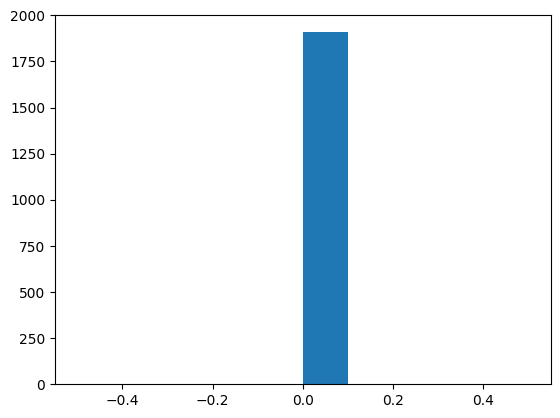

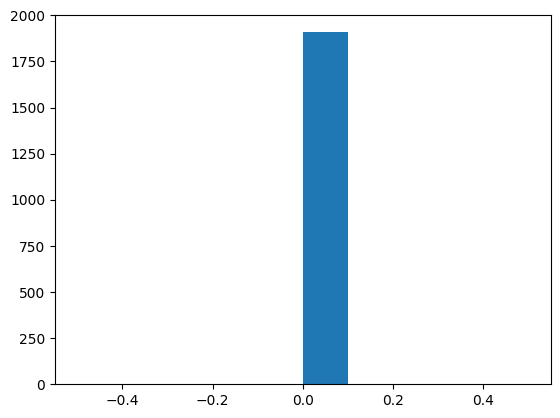

In [38]:
plt.hist(subm.FVC)
# plt.title("uncertainty in prediction")
# plt.savefig('subm.FVC{}.png'.format(index))
plt.show()

plt.hist(subm.FVC1)
# plt.title("uncertainty in prediction")
# plt.savefig('subm.FVC_1{}.png'.format(index))
plt.show()

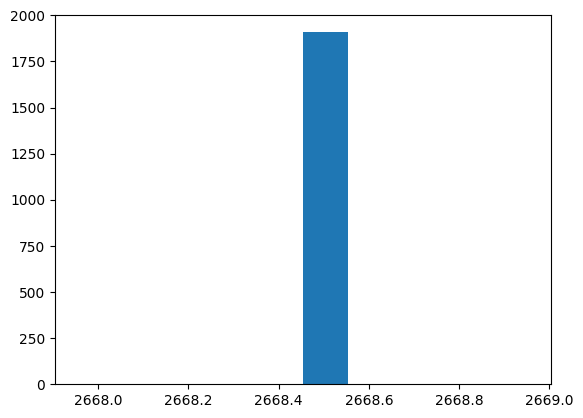

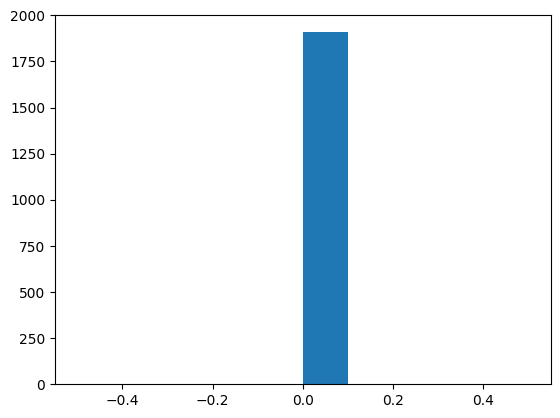

In [39]:
plt.hist(subm.Confidence)
# plt.title("uncertainty in prediction")
# plt.savefig('subm.Confidence{}.png'.format(index))
plt.show()

plt.hist(subm.Confidence1)
# plt.title("uncertainty in prediction")
# plt.savefig('subm.Confidence_1{}.png'.format(index))
plt.show()

In [40]:
subm.describe().T

,count,mean,std,min,25%,50%,75%,max
FVC,1908.0,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
Confidence,1908.0,2668.453623,3.502473e-11,2668.453623,2668.453623,2668.453623,2668.453623,2668.453623
FVC1,1908.0,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
Confidence1,1908.0,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000


In [41]:
otest = pd.read_csv('../input/osic-pulmonary-fibrosis-progression/test.csv')
for i in range(len(otest)):
    subm.loc[subm['Patient_Week']==otest.Patient[i]+'_'+str(otest.Weeks[i]), 'FVC'] = otest.FVC[i]
    subm.loc[subm['Patient_Week']==otest.Patient[i]+'_'+str(otest.Weeks[i]), 'Confidence'] = 0.1

In [42]:
subm[["Patient_Week","FVC","Confidence"]].to_csv("submission.csv", index=False)

In [43]:
subm

,Patient_Week,FVC,Confidence,FVC1,Confidence1
0,ID00126637202218610655908_-3,0,2668.453623,0.0,0.0
1,ID00126637202218610655908_-2,0,2668.453623,0.0,0.0
2,ID00126637202218610655908_-1,0,2668.453623,0.0,0.0
3,ID00126637202218610655908_0,0,2668.453623,0.0,0.0
4,ID00126637202218610655908_1,0,2668.453623,0.0,0.0
...,...,...,...,...,...
1903,ID00047637202184938901501_98,0,2668.453623,0.0,0.0
1904,ID00047637202184938901501_99,0,2668.453623,0.0,0.0
1905,ID00047637202184938901501_100,0,2668.453623,0.0,0.0
1906,ID00047637202184938901501_101,0,2668.453623,0.0,0.0


In [44]:
# !pip install jovian --upgrade --quiet

In [45]:
# import jovian

In [46]:
# jovian.commit(project='osic-new-era')

In [47]:
submm = pd.read_csv('../input/osic36175/submission_6.175.csv')
submm = submm.values
colnames = ['Patient','FVC_175', 'Confidence_175']
submm = pd.DataFrame(submm, columns=colnames)

FileNotFoundError: [Errno 2] No such file or directory: '../input/osic36175/submission_6.175.csv'

In [48]:
submm


NameError: name 'submm' is not defined

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


NameError: name 'submm' is not defined

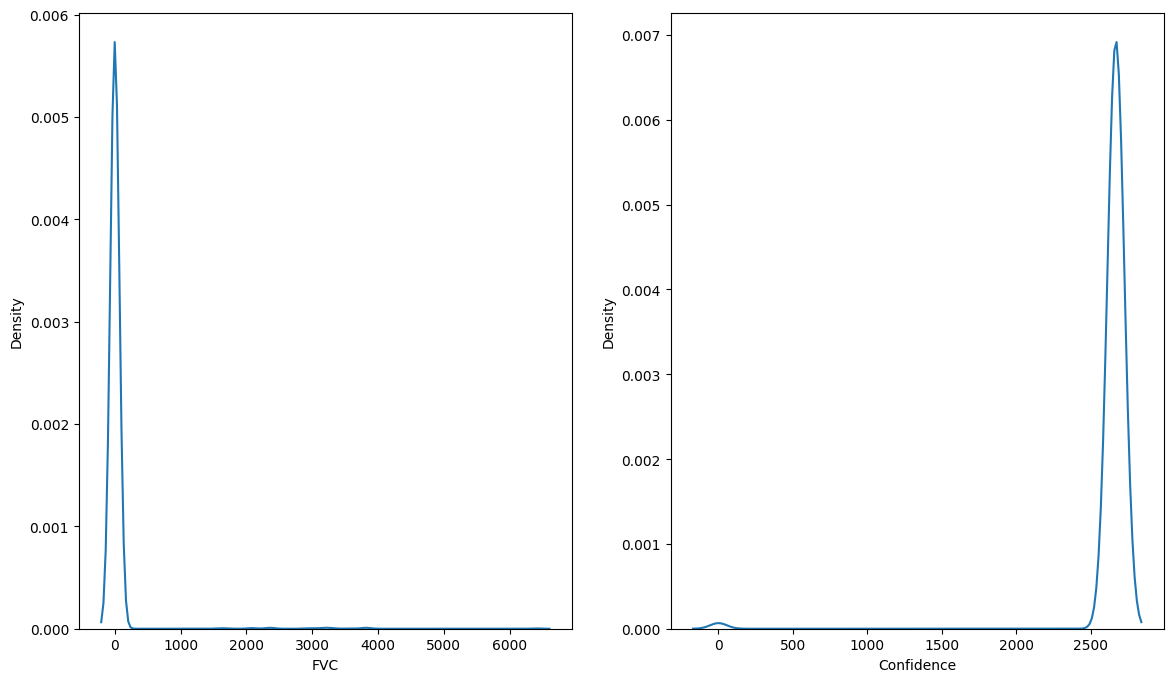

In [49]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 8))

sns.kdeplot(subm['FVC'], ax=ax1)
sns.kdeplot(subm['Confidence'], ax=ax2)

sns.kdeplot(submm['FVC_175'], ax=ax1)
sns.kdeplot(submm['Confidence_175'], ax=ax2)